# Day 5 — Matplotlib & Week 1 Mini-Notebook 

In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


task1: Load and clean a provided dataset with Pandas (handling any missing values)

In [2]:
# read the dataset
df = pd.read_csv('Mobile Price/train.csv')

In [3]:
print(f'null values: {df.isnull().sum()}')

null values: battery_power    2
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       1
m_dep            1
mobile_wt        1
n_cores          0
pc               0
px_height        1
px_width         1
ram              1
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [4]:
df.dropna(inplace=True) 

this dataset has no null values, so I manually deleted a small number of values, and deleting them does not affect the dataset.

task2:  Use NumPy to compute at least one derived numeric feature or summary statistic.

In [6]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='str')

In [ ]:
# Derived feature: screen area
df['screen_area'] = np.multiply(df['px_height'], df['px_width']) # Adding a new feature that represents the screen area using its dimensions.

df[['px_height', 'px_width', 'screen_area']].head()

,px_height,px_width,screen_area
0,20.0,756.0,15120.0
1,905.0,1988.0,1799140.0
2,1263.0,1716.0,2167308.0
5,1004.0,1654.0,1660616.0
6,381.0,1018.0,387858.0


task3:  Produce at least three labeled plots (including a histogram and a scatter plot) exploring the data.

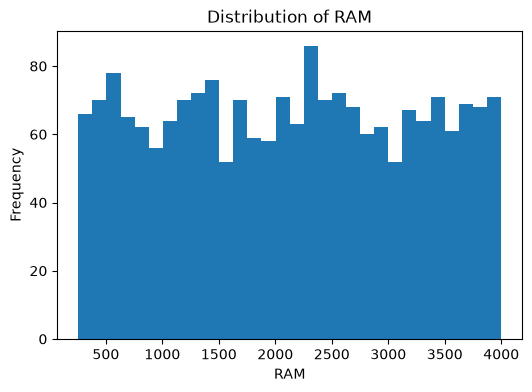

In [8]:
# 1. Histogram: Distribution of RAM
plt.figure(figsize=(6,4))
plt.hist(df['ram'], bins=30)
plt.title("Distribution of RAM")
plt.xlabel("RAM")
plt.ylabel("Frequency")
plt.show()

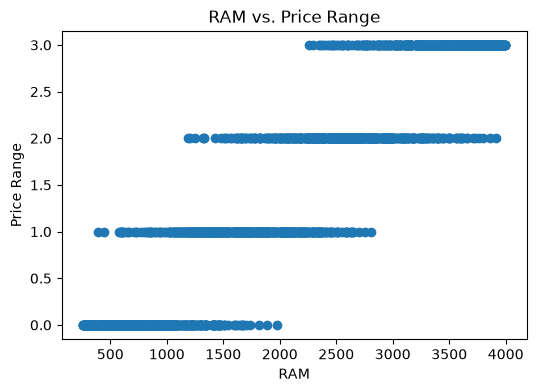

In [9]:
# 2. Scatter plot: RAM vs Price Range
plt.figure(figsize=(6,4))
plt.scatter(df['ram'], df['price_range'])
plt.title("RAM vs. Price Range")
plt.xlabel("RAM")
plt.ylabel("Price Range")
plt.show()

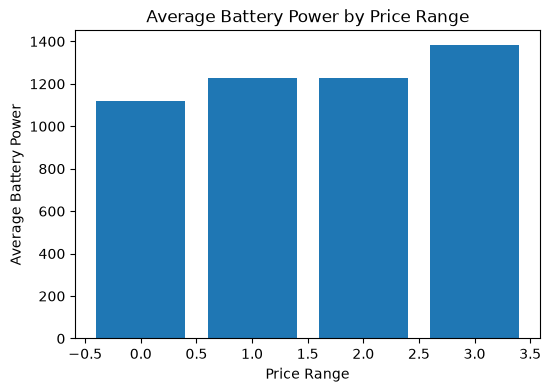

In [10]:
# 3. Bar plot: Average Battery Power by Price Range
avg_battery = df.groupby('price_range')['battery_power'].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_battery.index, avg_battery.values)
plt.title("Average Battery Power by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Battery Power")
plt.show()

task4: Write Markdown cells explaining what each visualization reveals about the data

**Distribution of RAM**

RAM values are roughly **uniformly distributed** between ~300 and 4000, 
with no strong skew, outliers, or bimodal pattern. This suggests discrete 
hardware spec values spread evenly across the sample, rather than a 
naturally skewed variable. No transformation is needed before further use.

**RAM vs. Price Range**

There is a clear **positive relationship** between RAM and Price Range: 
higher RAM values consistently correspond to higher price categories, with 
the four price ranges (0–3) forming distinct horizontal bands rather than 
overlapping. RAM appears to be one of the strongest predictors of price 
range in this dataset, making it a valuable feature for a classification model.

**Average Battery Power by Price Range** 

Average battery power increases slightly with price range, but the 
relationship is much weaker than with RAM — price ranges 1 and 2 have 
nearly identical averages (~1230), and only price range 3 stands out with 
a noticeably higher average (~1390). This suggests battery power has a 
mild positive association with price but is a much less discriminating 
feature than RAM.

## task5: Commit the finished notebook and its requirements.txt to GitHub with a clear commit message. (**Done**)